In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [32]:
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')

In [55]:
df.shape

(1303, 6)

In [33]:
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [44]:
df.loc[len(df)] = [7.0,	14.0,8.0,7.0,220.0,'green']
df.loc[len(df)] = [6.9,25.0,4.0,4.0,-330.0,'green']
df.loc[len(df)] = [7.0,579.0,3.0,3.0,-230.0,'green']

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_1148\3138402172.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sig'])
C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_1148\3138402172.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['mmi'])


<Axes: xlabel='mmi', ylabel='Density'>

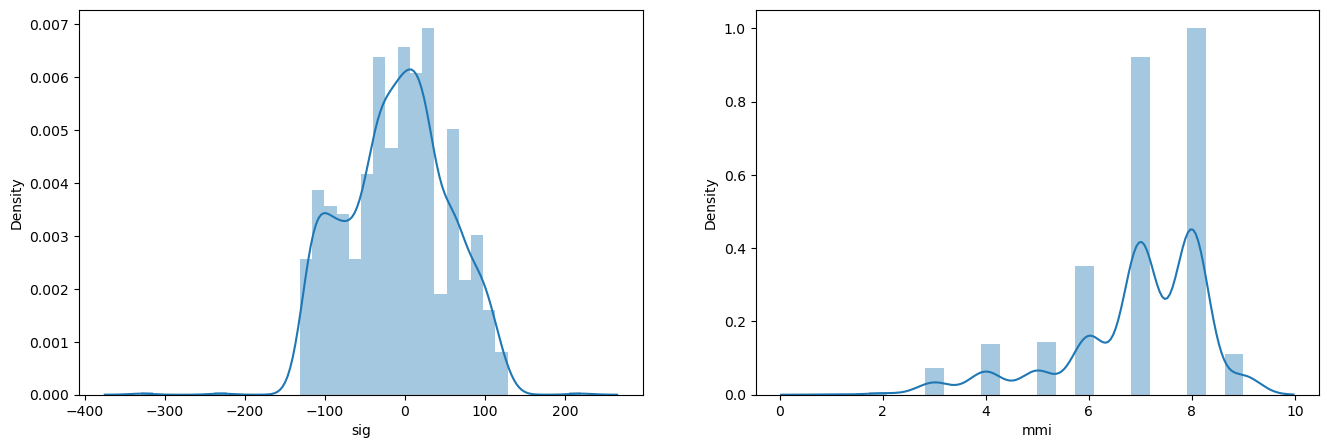

In [45]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['sig'])

plt.subplot(1,2,2)
sns.distplot(df['mmi'])


In [46]:
df['sig'].describe()

count    1303.000000
mean       -9.987721
std        63.419663
min      -330.000000
25%       -54.000000
50%        -7.000000
75%        31.000000
max       220.000000
Name: sig, dtype: float64

In [51]:
# Find the Limit
highest = df['sig'].mean() + 3 * df['sig'].std()
lowest = df['sig'].mean() - 3 * df['sig'].std()

In [52]:
highest, lowest

(180.27126735033585, -200.24670863966816)

In [53]:
# Finding the Outliers
df[(df['sig'] > highest) | (df['sig'] < lowest)]

,magnitude,depth,cdi,mmi,sig,alert
1300,7.0,14.0,8.0,7.0,220.0,green
1301,6.9,25.0,4.0,4.0,-330.0,green
1302,7.0,579.0,3.0,3.0,-230.0,green


In [54]:
# Trimming
new_df = df[(df['sig'] < highest) & (df['sig'] > lowest)]
new_df

,magnitude,depth,cdi,mmi,sig,alert
0,7.00,14.0,8.0,7.0,0.0,green
1,6.90,25.0,4.0,4.0,-33.0,green
2,7.00,579.0,3.0,3.0,-13.0,green
3,7.30,37.0,5.0,5.0,65.0,green
4,6.60,624.0,0.0,2.0,-98.0,green
...,...,...,...,...,...,...
1295,6.87,11.0,9.0,7.0,13.0,yellow
1296,7.85,93.0,8.0,6.0,-51.0,yellow
1297,7.48,142.0,7.0,6.0,120.0,yellow
1298,7.04,51.0,7.0,6.0,-115.0,yellow


In [58]:
# Capping 
df['sig'] = np.where(df['sig']<lowest,lowest,
                    np.where(df['sig']>highest,highest,df['sig']))

In [59]:
df.shape

(1303, 7)

In [60]:
df['sig'].describe()

count    1303.000000
mean       -9.895796
std        62.841024
min      -200.246709
25%       -54.000000
50%        -7.000000
75%        31.000000
max       180.271267
Name: sig, dtype: float64